# **Bank Telemarketing Dataset -- Campaign EDA Approach**

In [56]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

In [57]:
import sys
sys.path.append("..")
from src import my_file

## Display Setting

In [58]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [59]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [60]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [61]:
tele_df.shape

(41188, 21)

In [62]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [63]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [64]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Campaign Data Description:**

- **campaign**: Number of contacts performed during this campaign for this client (numeric, includes last contact)
- **pdays**: Number of days since the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
- **previous**: Number of contacts performed before this campaign for this client (numeric) 
- **poutcome**: Outcome of the previous marketing campaign (categorical: 'failure', 'nonexistent', 'success')
- **duration**: Duration of the last contact in seconds (numeric)
Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model


## **Formatting and Consistency Check**

In [65]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis**

**Target Variable**

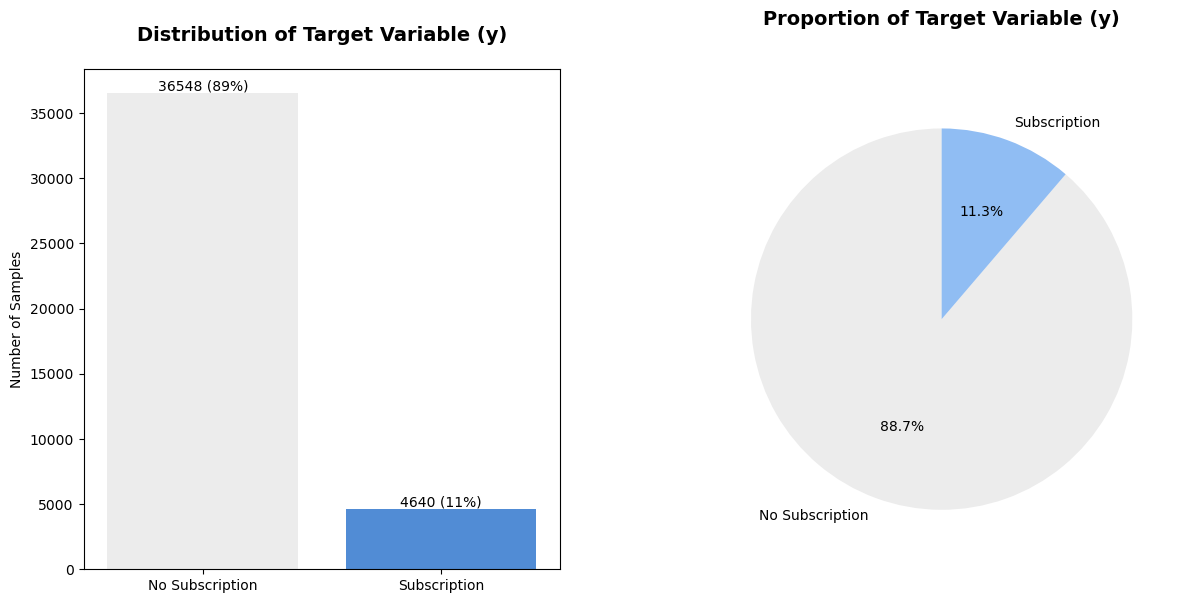

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [67]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

## **Exploratory Data Analysis ---- Campaign attributes**

In [68]:
# campaign columns along with term-depost features and month as well for trend
campaign_cols = ['contact', 'duration','campaign', 'pdays', 'previous', 'poutcome', 'month', 'y', 'y_binary']
campaign_df = tele_df[campaign_cols]

**Considering the given dataset is about customer subscribe for term deposit will depends upon how customers approach during campaign each month, had an impact on customer's decision i.e., tareget y. Hence, decide to analyze deeper the month dimension.**

In [69]:
# Just a remainder, the observations are ordered by date (from may 2008 to november 2010) 
# reorder month column as per natural order of months
months_arr = [
    [i, m] for i, m in enumerate(tele_df['month'])
    if i == 0 or m != tele_df['month'].iloc[i-1]
]
months_arr = np.array(months_arr)

__We got :__

__2008 : [0, 27690)__

__2009 : [27690, 39130)__

__2010 : [39130, 41188)__

In [70]:
# Create year as a column
tele_df['year'] = np.hstack(
    (np.array([2008]*(27690-0)),
    np.array([2009] * (39130 - 27690)),
    np.array([2010] * (41188 - 39130)))
    )

tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary', 'year'],
      dtype='object')

In [71]:
# Universal months order
order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
tele_df['month_order'] = pd.Categorical(tele_df['month'], categories=order, ordered=True)

In [72]:
list_cols = campaign_df.columns.to_list()
list_cols.extend(['year', 'month_order'])
campaign_df = tele_df[list_cols]
campaign_df.head(2)

,contact,duration,campaign,pdays,previous,poutcome,month,y,y_binary,year,month_order
0,telephone,261,1,999,0,nonexistent,may,no,0,2008,may
1,telephone,149,1,999,0,nonexistent,may,no,0,2008,may


### **Dimension Analysis**

**Dimension : `contact`**

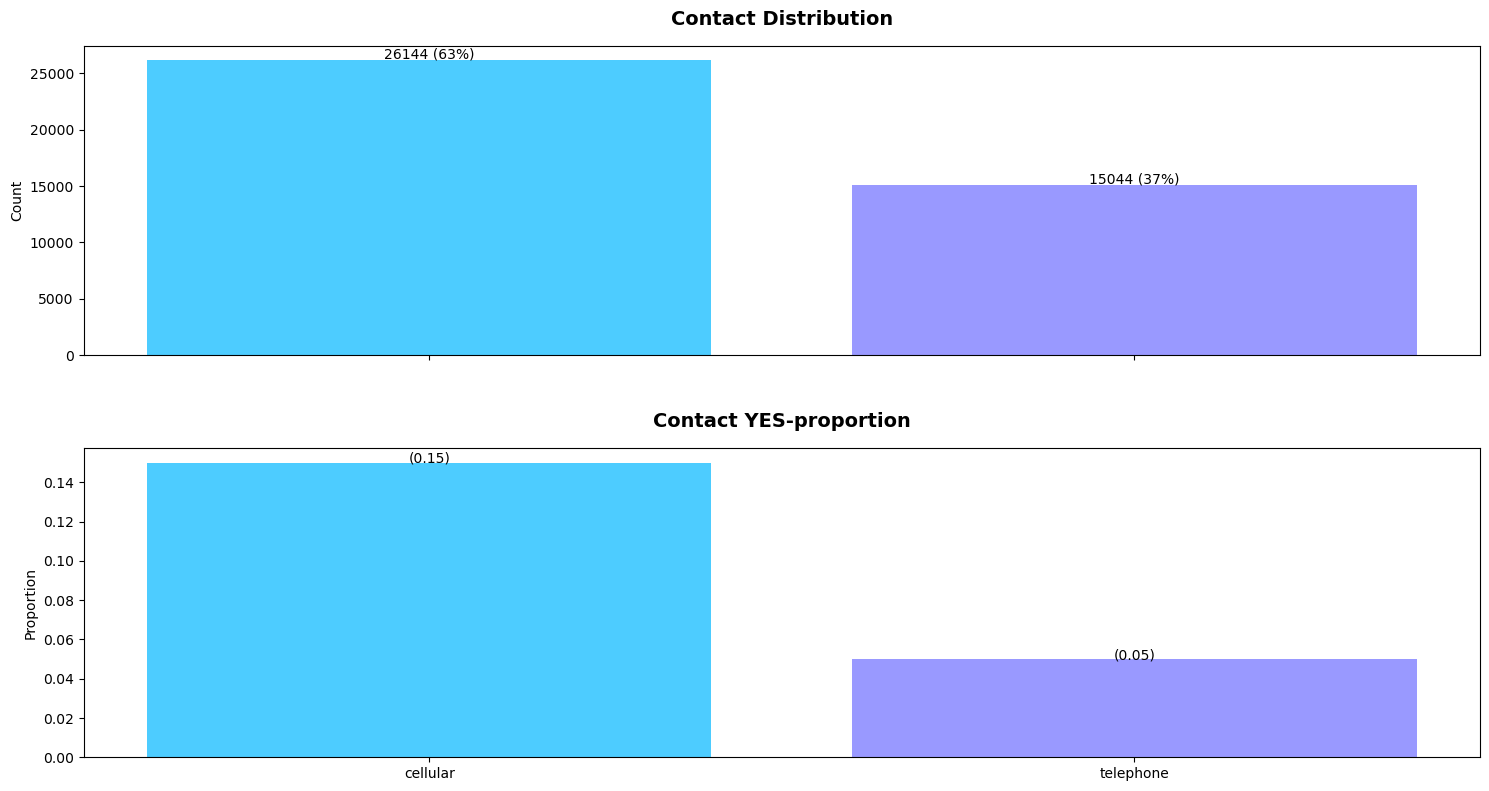

In [73]:
contact_counts, fig = my_file.plot_univariate_analysis_categorical_var(tele_df, 'contact', 'y', 'Contact')


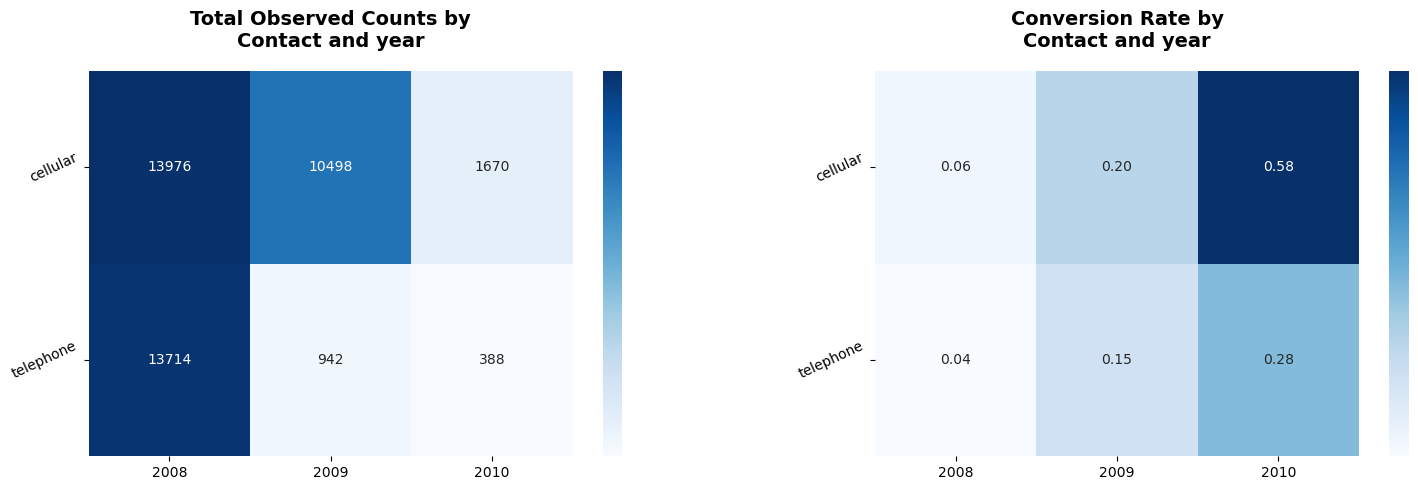

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_heatmap_bivariate_analysis(tele_df, 'contact', 'year', 'y_binary',fig=fig, ax=ax);

- Client contacted through `cellular` category look like tend to subscribe more(based on barplot of contact yes-proportion), and this pattern continues by year also (based on heatmap or second map) but most interesting thing is there is big difference in year 2010. Let's dig in:

`Cellular` contacts by Months

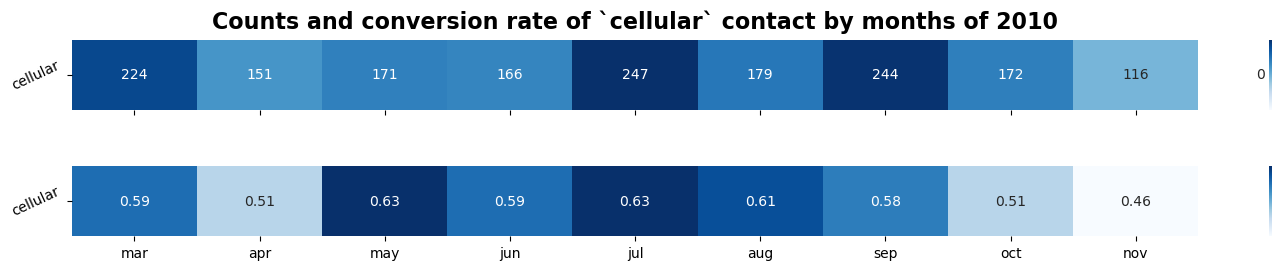

In [75]:
fig, ax = plt.subplots(2, 1, figsize=(15, 3), sharex=True)
my_file.plot_heatmap_bivariate_analysis(
    tele_df[(tele_df['contact']=='cellular') & (tele_df['year']==2010)], 'contact', 
    'month_order', 'y_binary', fig=fig, ax=ax)

ax[0].set_title("Counts and conversion rate of `cellular` contact by months of 2010", fontsize=16, fontweight='bold', y=1.05)
ax[1].set_title("")
plt.subplots_adjust(wspace=0.3, hspace=0.8)
plt.show()

`Telephone` contacts by Months

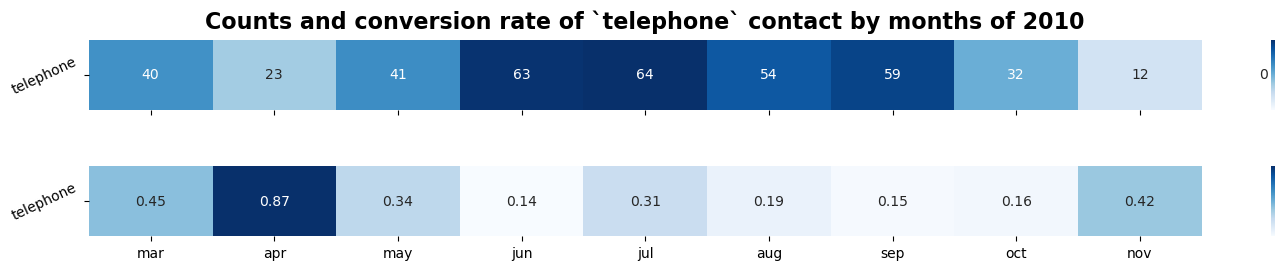

In [76]:
fig, ax = plt.subplots(2, 1, figsize=(15, 3), sharex=True)
my_file.plot_heatmap_bivariate_analysis(
    tele_df[(tele_df['contact']=='telephone') & (tele_df['year']==2010)], 'contact', 
    'month_order', 'y_binary', fig=fig, ax=ax)

ax[0].set_title("Counts and conversion rate of `telephone` contact by months of 2010", fontsize=16, fontweight='bold', y=1.05)
ax[1].set_title("")
plt.subplots_adjust(wspace=0.3, hspace=0.8)
plt.show()

We got an anomaly high YES-proportion for `cellular` type of a contact in 2010. The reason so far is unknown.

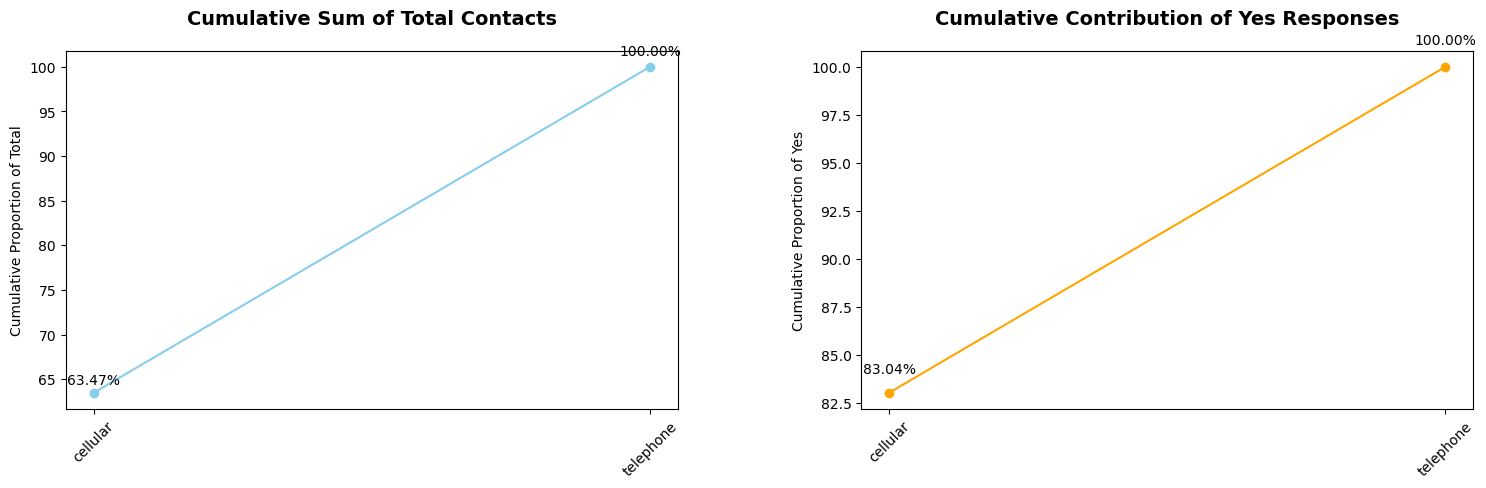

In [77]:
# cumulative total counts and yes response by contact features
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_cumsum_total_yes_response(contact_counts, 'contact', 'cumsum_total_proportion', 'cumsum_yes_proportion', fig=fig, ax=ax);


In [78]:
# Statistical test for relationship between categorical variables and y(term deposit)
def chi_square_categorical_y(data, feature_var, target_var):
    # Contingency table
    table = pd.crosstab(data[feature_var], data[target_var])

    # Chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Compute Cramér's V
    n = table.sum().sum()
    k = min(table.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1)))
    significance = 'small' if cramers_v < 0.1 else 'medium' if cramers_v < 0.3 else 'large' if cramers_v < 0.5 else 'very large'
    df = pd.DataFrame(
        [chi2, p, cramers_v, significance], index=['Chi-square', 'pvalue', 'cramers_v', 'effect_size'], columns=['statistical_values'])

    df = df.round(4)
    return df

# Chi-square test between cellular and y
chi_square_categorical_y(tele_df, 'contact', 'y')

,statistical_values
Chi-square,862.318364
pvalue,0.0
cramers_v,0.144693
effect_size,medium


- **Association between cellular and y is moderate.**

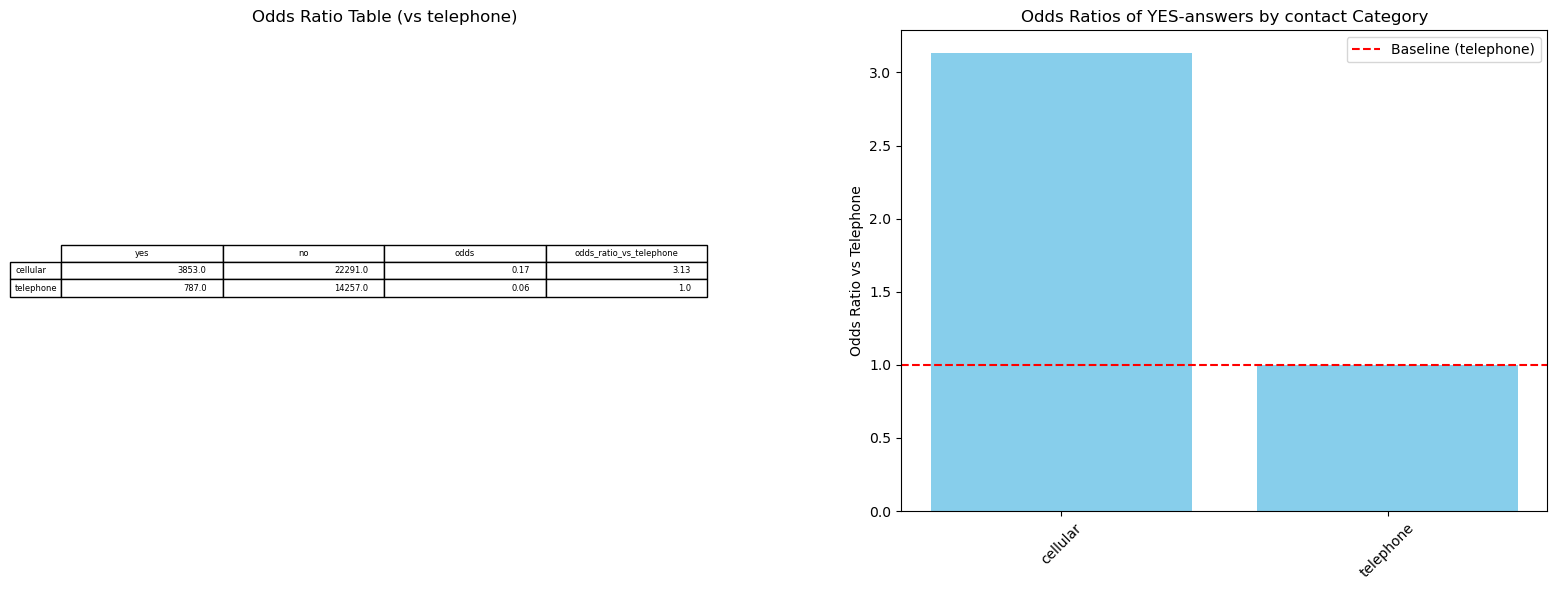

In [79]:
my_file.plot_odd_ratio_table(tele_df, 'contact', 'y', 'telephone');

- **Client contacted during campaign on `cellular` category are three times more likely to subscribe compared to `telephone` category.**

**Conclusion :**

- During campaign client with cell phone(cellular) contacted (~63%) more than telephone client(~37%).
- Cellular contacts consistently yielded higher converstion rates than telephone.
- Later year (2010) were more effective.
- shows that cellular in 2010 had the best converstion performance. 

**Dimaension : `duration`**

duration: last contact duration, in seconds (numeric).

Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

In [80]:
dtype_df.loc['duration', :]

dtype                                                  int64
nunique                                                 1544
unique     [261, 149, 226, 151, 307, 198, 139, 217, 380, ...
Name: duration, dtype: object

In [81]:
np.linspace(start=tele_df['duration'].min(), stop=tele_df['duration'].max(), num=5)

array([   0. , 1229.5, 2459. , 3688.5, 4918. ])

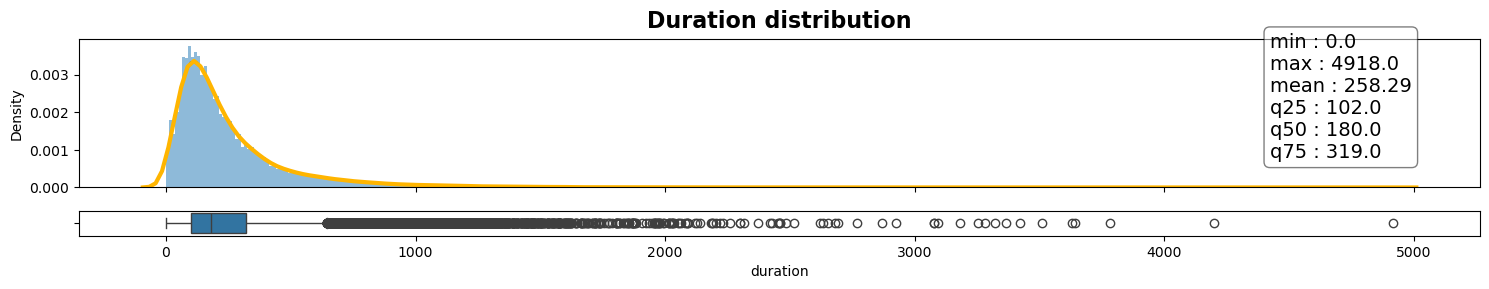

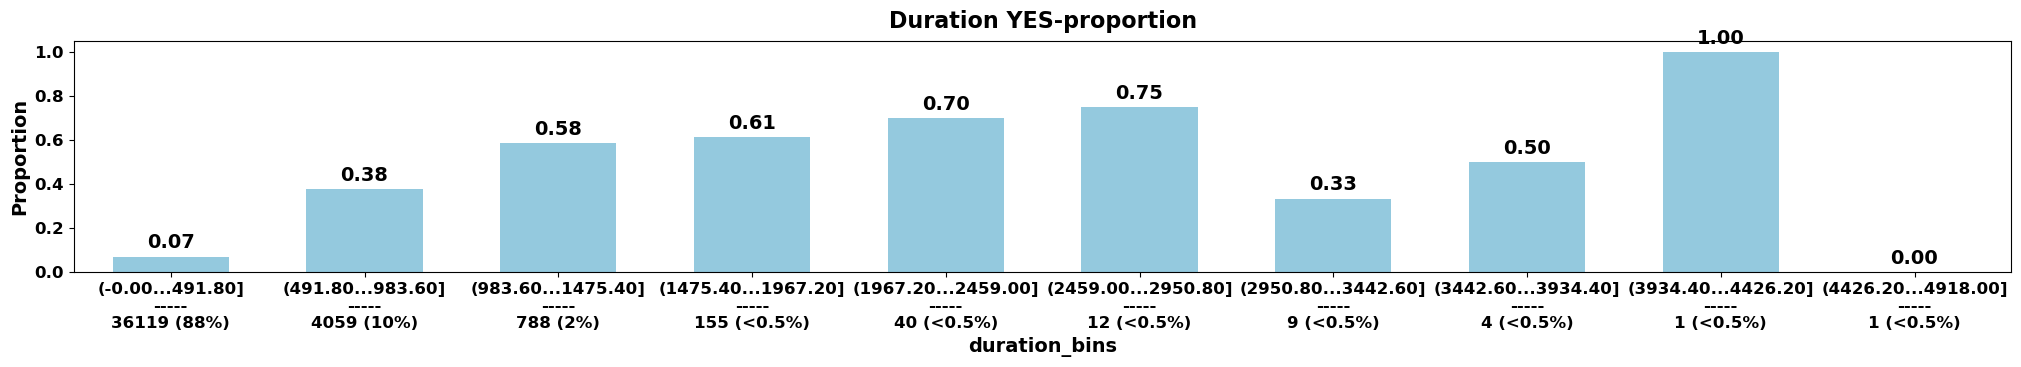

In [82]:
my_file.plot_numeric_distribution(tele_df, 'duration');
fig, ax = plt.subplots(figsize=(25, 3))
my_file.plot_numeric_yes_proportion(tele_df, 'duration', 'y_binary', 10, 0.6, ax=ax, fig=fig)
plt.show()

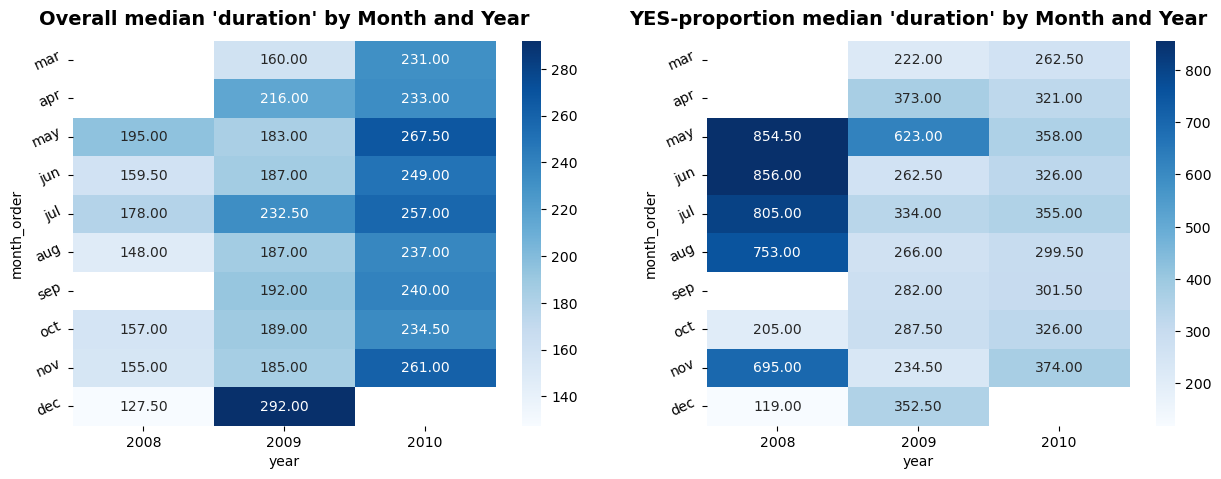

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'duration', 'Month', fig=fig, ax=ax);

- Clients with higher duration are more like to subscribe to term deposit(as per heatmap plot or second plot) and higher duration changes over years and months as well.

In [84]:
feature_name = 'duration'
print(f'Pearson corr. coef. ({feature_name} vs y): {tele_df[feature_name].corr(tele_df["y_binary"]):.4f}')

Pearson corr. coef. (duration vs y): 0.4053


- There is correlation between `duration and y`.

Check descripitve statistics distribution of yes-no answers.

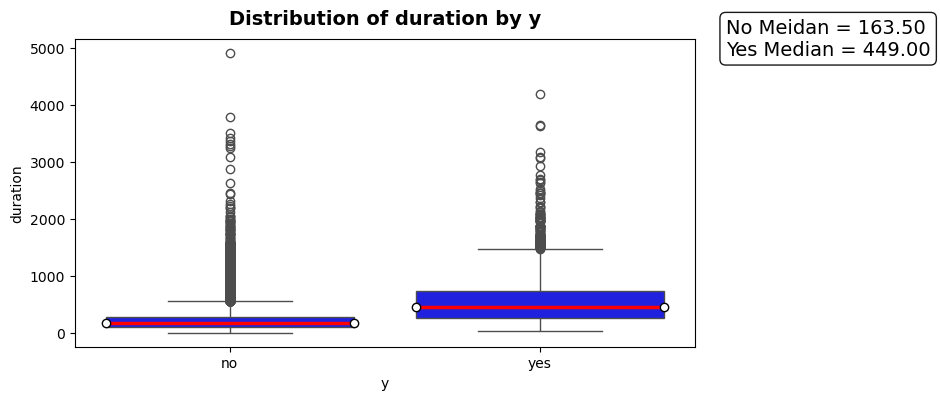

In [85]:
fig, ax = plt.subplots(figsize=(8, 4))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'duration', fig=fig, ax=ax);

In [86]:
print("Various descriptive statistics of `duration` by `y`\n")
print(tele_df.groupby(['y'])['duration'].describe().round(2))

Various descriptive statistics of `duration` by `y`

       count    mean     std   min    25%    50%     75%     max
y                                                               
no   36548.0  220.84  207.10   0.0   95.0  163.5  279.00  4918.0
yes   4640.0  553.19  401.17  37.0  253.0  449.0  741.25  4199.0


Clearly, there is huge difference between yes-no median and that's why this feature is useful for classification. Furthur, can be used of statistical analysis as well for more evidence.

In [87]:
data = my_file.var_by_year(tele_df, 'year', 'duration')
data['std'] = (np.sqrt(data['variation of `duration`'])/60).round(2)
data['var_over_year'] = data['variation of `duration`'].pct_change().round(4)
data

,variation of `duration`,Number of observatios(%),std,var_over_year
year,,,,
2008,68608.05,67.2,4.37,NaN
2009,63795.97,27.8,4.21,-0.0701
2010,64929.54,5.0,4.25,0.0178


So across years, **spread of duration calls** is consistently around **4 minutes**, with only tiny differences of a few seconds. **Call duration variability stayed stable across years.**

**Conclusion :**

- If we consider only first 3-4 bins(with sufficient number of observations), it's obvious that longer duration call has higher chance to get positive decision.

- And we also shouldn't forget about the important note, that says: "this attribute highly affects the output target (e.g., if duration=0 then y='no')".


**Dimension : `campaign`**

campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

In [88]:
dtype_df.loc['campaign',:]

dtype                                                  int64
nunique                                                   42
unique     [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 19...
Name: campaign, dtype: object

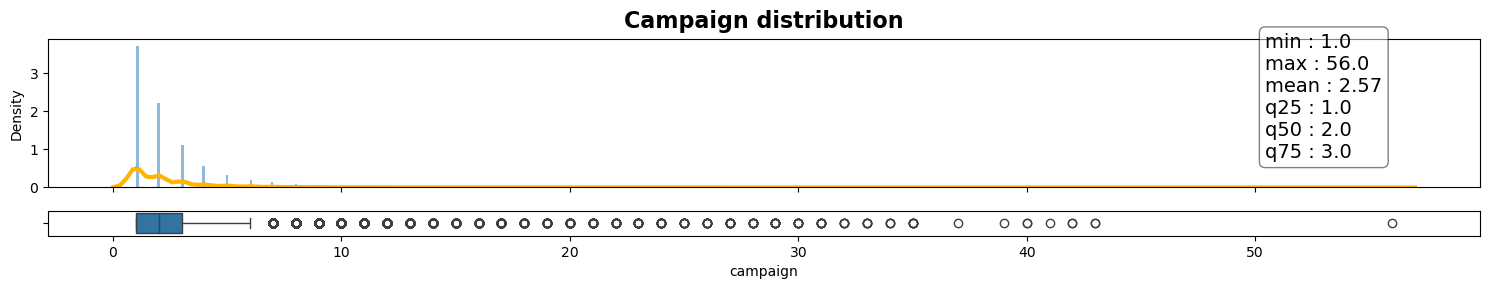

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


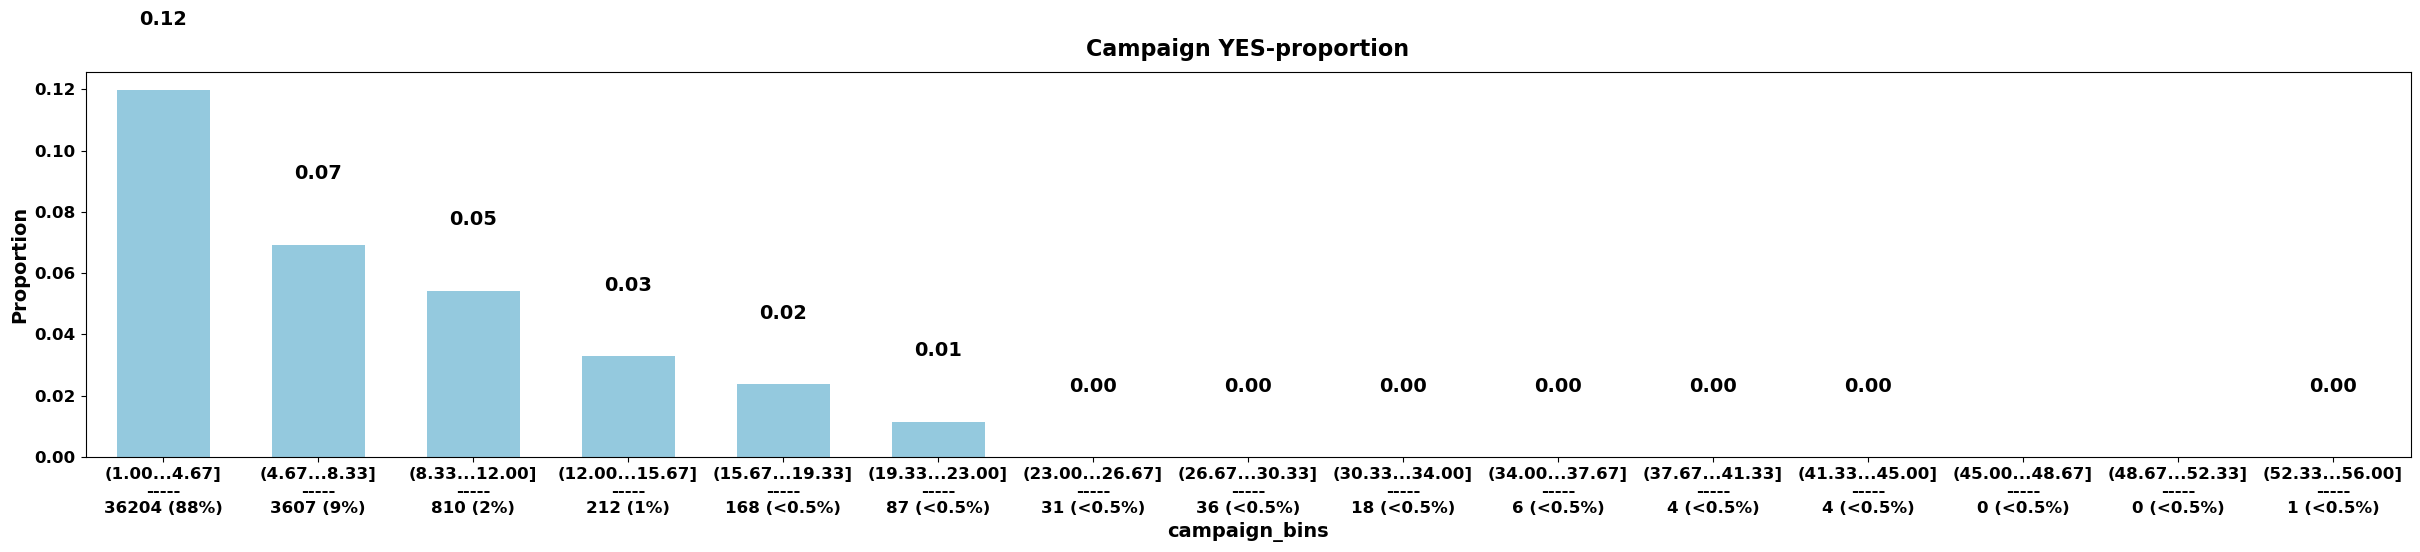

In [99]:
my_file.plot_numeric_distribution(tele_df, 'campaign');
fig, ax = plt.subplots(figsize=(30, 5))
my_file.plot_numeric_yes_proportion(tele_df, 'campaign', 'y_binary', 15, 0.6, ax=ax, fig=fig)
plt.show()

Look at first bin(from 1 to 4 contacts) and try to see if yes-proportion is affected by the number of contacts during campaign.

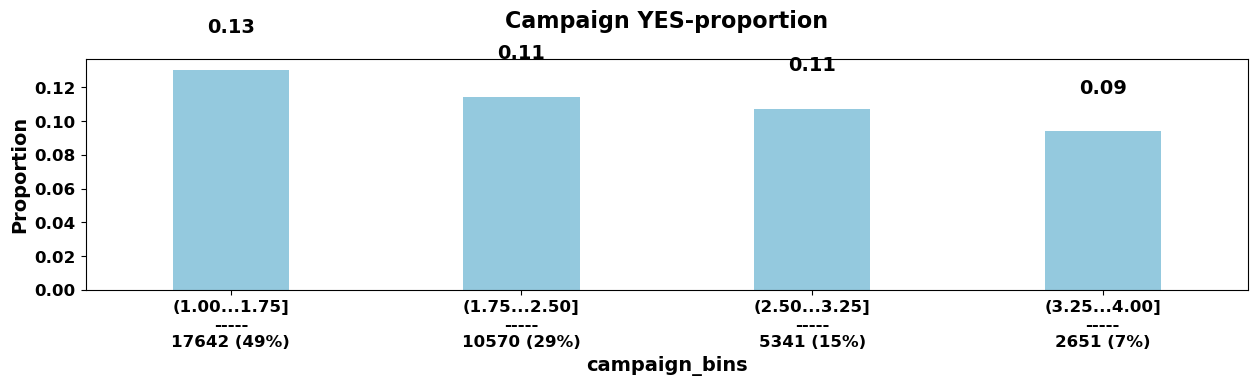

In [101]:
fig, ax = plt.subplots(figsize=(15, 3))
my_file.plot_numeric_yes_proportion(tele_df[tele_df['campaign'] <= 4], 'campaign', 'y_binary', num_grp=4, widths=0.4, ax=ax, fig=fig)
ax.set_title("Campaign YES-proportion", fontsize=16, fontweight='bold', y=1.10)
plt.show()

The above plot shows that as the number of contacts increases during campaign the likelihood of getting YES-response decreases. but on the other hand, every time we get additional positive answers from people who didn't agree previously, Yes, the proportion is getting decrease.

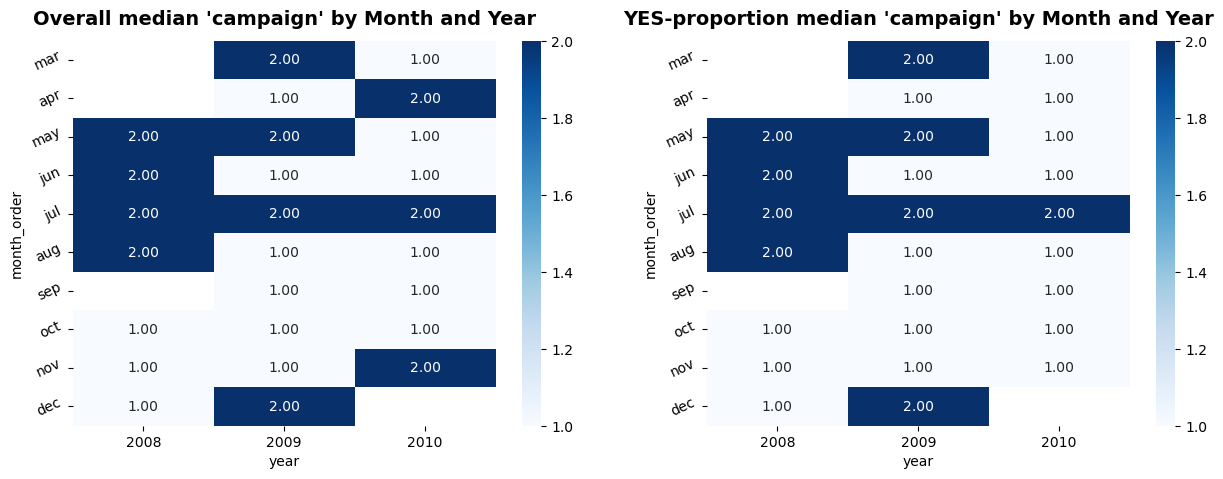

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'campaign', 'Month', fig=fig, ax=ax)
plt.show()

The no difference between median of yes and overall data (from the heatmap plot or second plot).

In [92]:
feature_name = 'campaign'
print(f'Pearson corr. coef. ({feature_name} vs y): {tele_df[feature_name].corr(tele_df["y_binary"]):.4f}')


Pearson corr. coef. (campaign vs y): -0.0664


- There is no correlation between `campaign and y`.

Check descriptive statistics distribution pf yes-no answers.

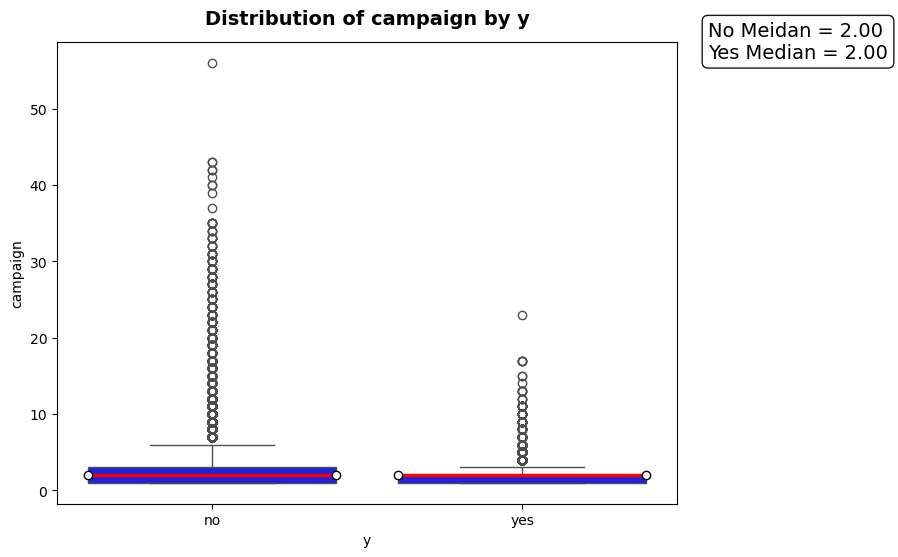

In [93]:
fig, ax = plt.subplots(figsize=(8, 6))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'campaign', fig=fig, ax=ax)
plt.show()

In [94]:
print("Various descriptive statistics of `campaign` by `y`\n")
print(tele_df.groupby(['y'])['campaign'].describe().round(2))

Various descriptive statistics of `campaign` by `y`

       count  mean   std  min  25%  50%  75%   max
y                                                 
no   36548.0  2.63  2.87  1.0  1.0  2.0  3.0  56.0
yes   4640.0  2.05  1.67  1.0  1.0  2.0  2.0  23.0


The median value number of contacts is similar whether the client subscribed or not. So, the central tendency of campaign calls doesn’t distinguish between outcomes.
The number of contacts alone is not a strong predictor of subscription. Quality of interaction or other features (like duration, pdays, or socio-economic indicators) likely play a bigger role.

In [95]:
data = my_file.var_by_year(tele_df, 'year', 'campaign')
data['std'] = np.sqrt(data['variation of `campaign`']).round(2)
data['var_over_year'] = data['variation of `campaign`'].pct_change().round(2)
data

,variation of `campaign`,Number of observatios(%),std,var_over_year
year,,,,
2008,9.93,67.2,3.15,NaN
2009,2.85,27.8,1.69,-0.71
2010,1.86,5.0,1.36,-0.35


**2008** (std = 3.15) : Campaign contacts varied widely. Some clients were called only once or twice, while others were contacted many times. This suggests a less consistent telemarketing approach.

**2009** (std = 1.69) : Variability dropped significantly. The bank began standardizing its strategy, with fewer extremes in the number of contacts per client.

**2010** (std = 1.36) : Variability was even lower. Most clients were contacted a similar number of times, indicating a more disciplined and uniform campaign process.

**Conclusion :**

- Nearly 43% were contacted only once.
- 88% of people were contacted less than 5 times.
- If we consider only first 2 bins(with sufficient number of observations), it's obvious that less number of contacts has higher chance to get positive response.

**Dimension : `pdays`**

pdays: Number of days since the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)

In [96]:
dtype_df.loc['pdays', :]

dtype                                                  int64
nunique                                                   27
unique     [999, 6, 4, 3, 5, 1, 0, 10, 7, 8, 9, 11, 2, 12...
Name: pdays, dtype: object

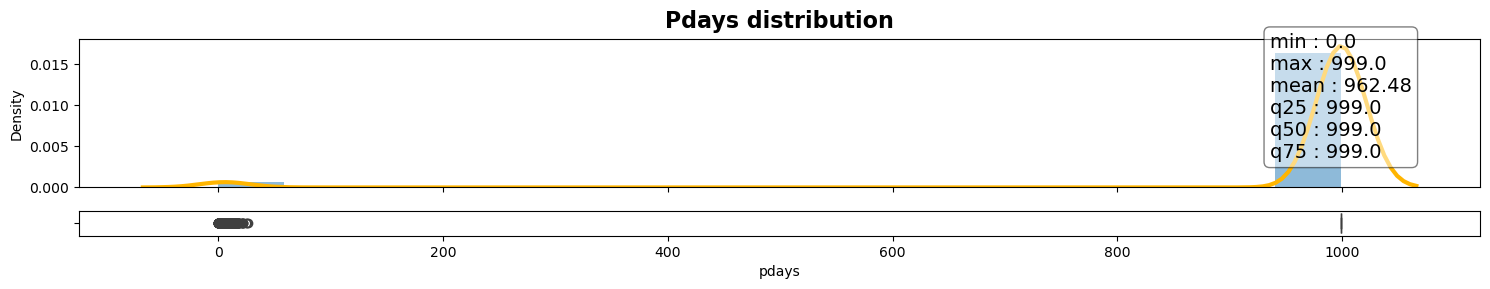

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


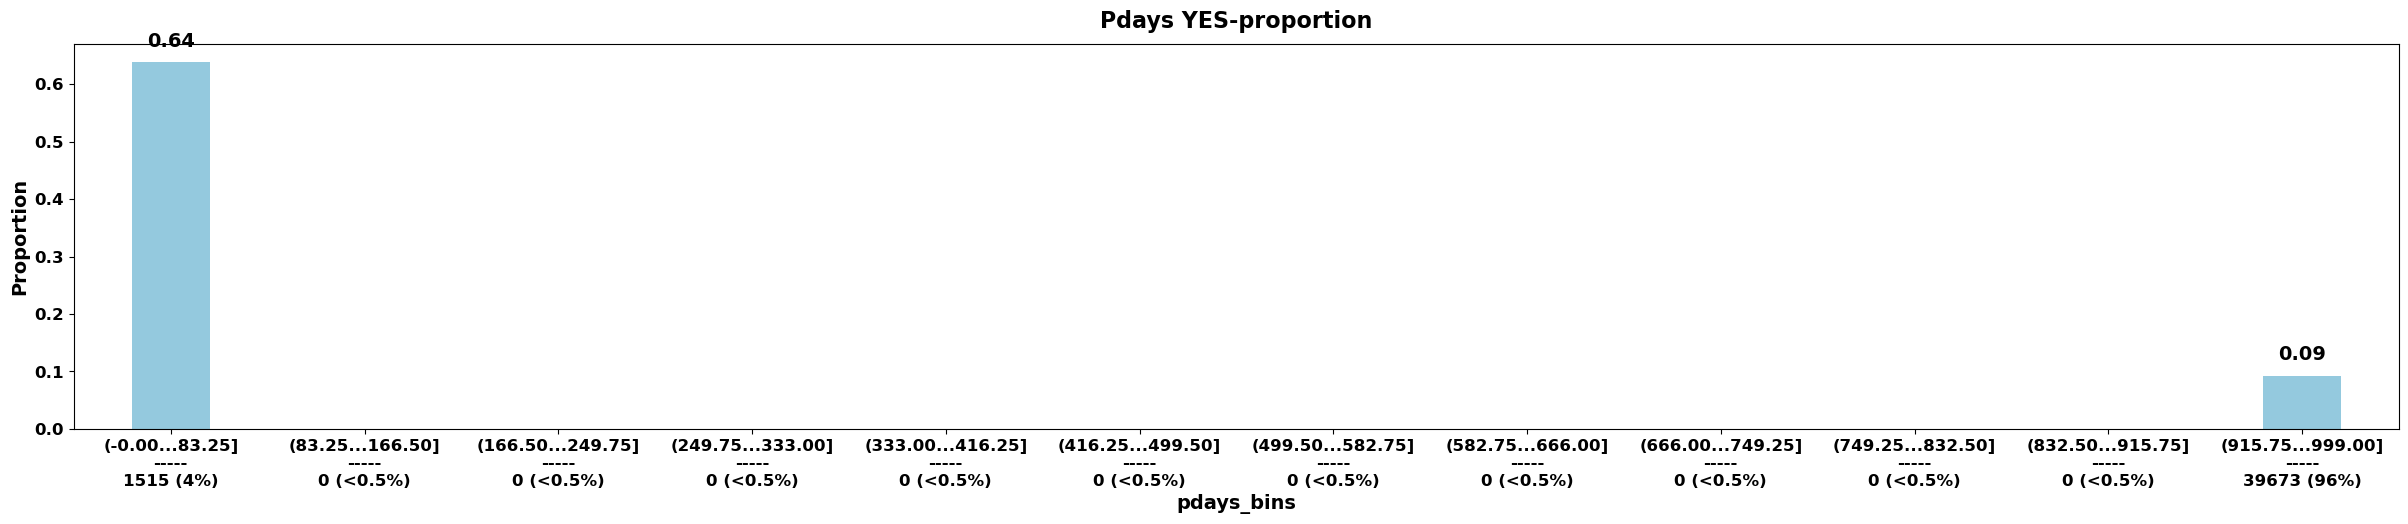

In [97]:
my_file.plot_numeric_distribution(tele_df, 'pdays')
fig, ax = plt.subplots(figsize=(30, 5))
my_file.plot_numeric_yes_proportion(tele_df, 'pdays', 'y_binary', 12, 0.4, ax=ax, fig=fig)
plt.show()

Let's replace 999 with -1 and repeat the analysis

In [109]:
tele_df['pdays_new'] = tele_df['pdays'].replace({999 : -1})

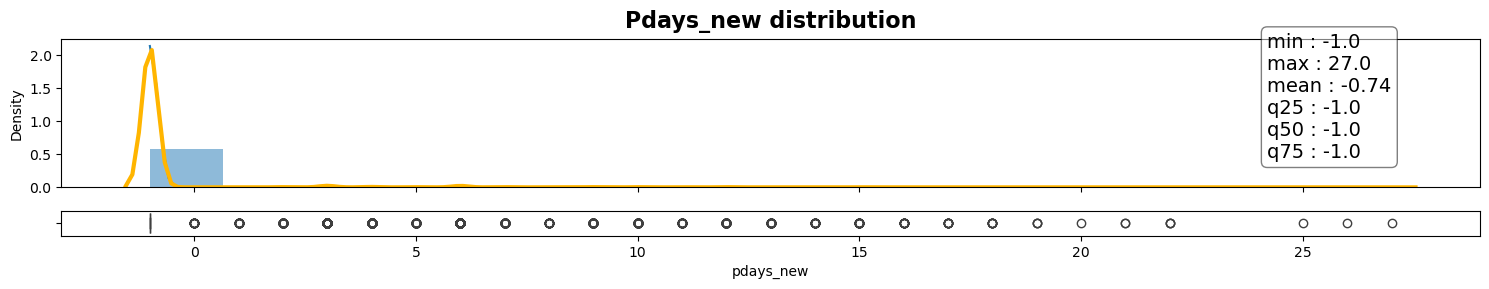

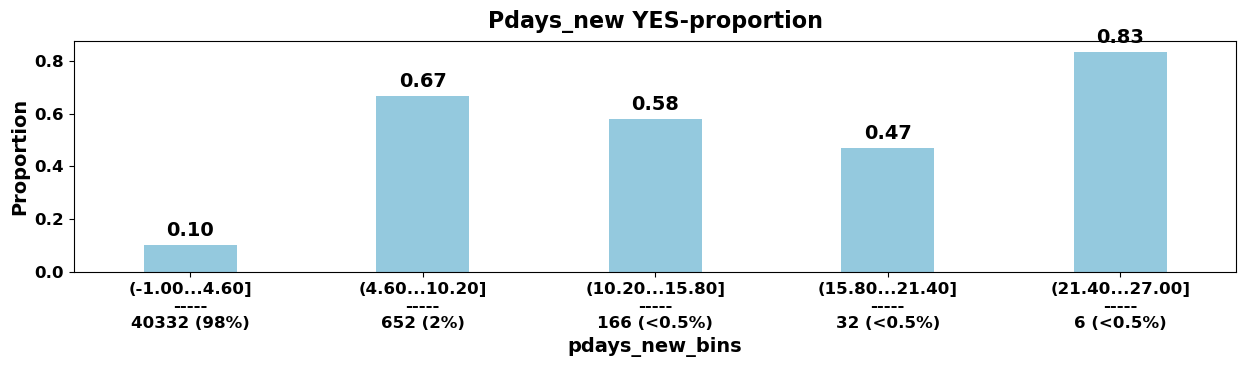

In [112]:
my_file.plot_numeric_distribution(tele_df, 'pdays_new')
fig, ax = plt.subplots(figsize=(15, 3))
my_file.plot_numeric_yes_proportion(tele_df, 'pdays_new', 'y_binary', 5, 0.4, ax=ax, fig=fig)
plt.show()

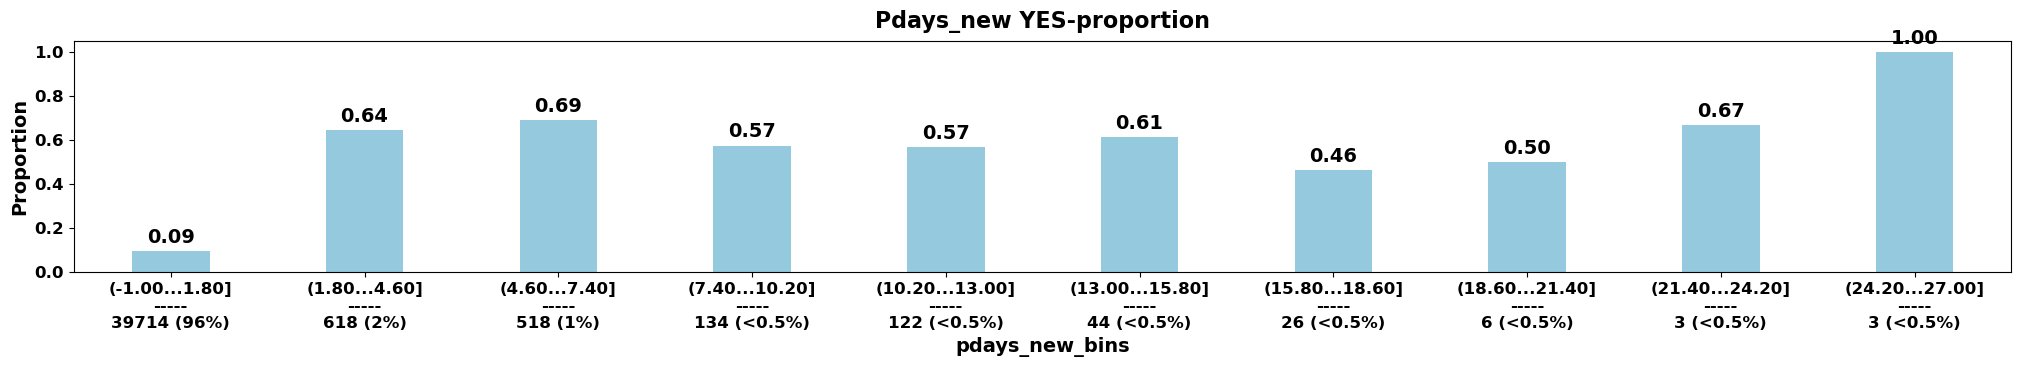

In [117]:
fig, ax = plt.subplots(figsize=(25, 3))
my_file.plot_numeric_yes_proportion(tele_df, 'pdays_new', 'y_binary', 10, 0.4, ax=ax, fig=fig)
plt.show()

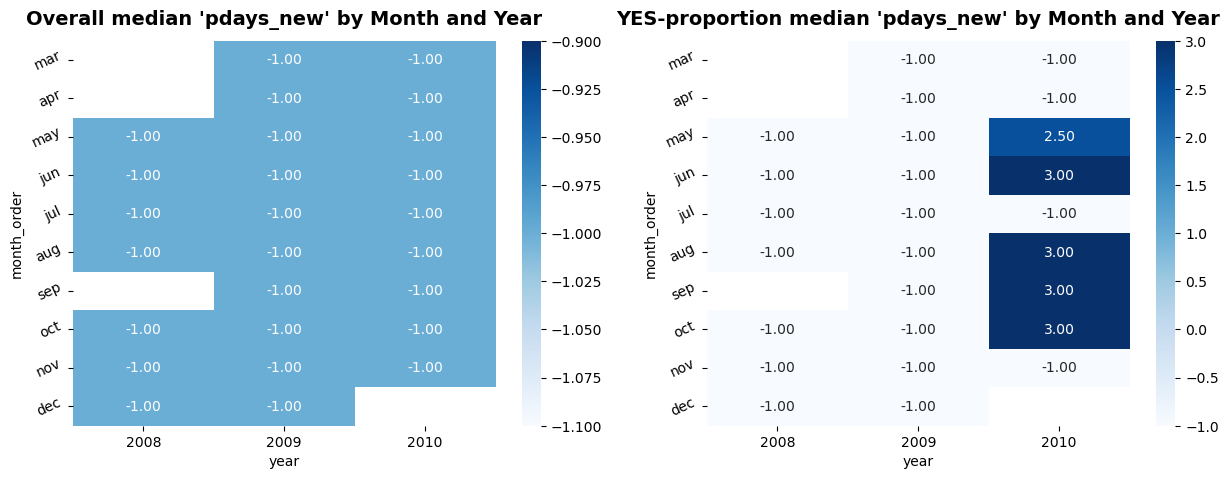

In [119]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
my_file.plot_numeric_heatmap_bivariate_analysis(tele_df, 'month_order', 'year', 'pdays_new', 'Month', fig=fig, ax=ax)
plt.show()


In [120]:
feature_name = 'pdays_new'
print(f'Pearson corr. coef. ({feature_name} vs y): {tele_df[feature_name].corr(tele_df["y_binary"]):.4f}')


Pearson corr. coef. (pdays_new vs y): 0.2790


- There is a weak correlation between `pdays and y`.

Check descriptive statistics distribution of yes-no response

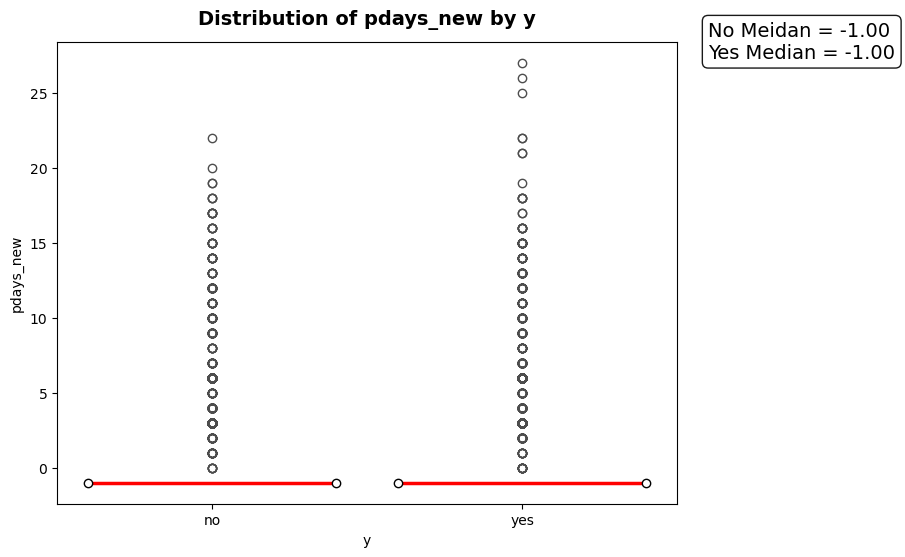

In [121]:
fig, ax = plt.subplots(figsize=(8, 6))
my_file.plot_boxplot_yes_no_distribution(tele_df, 'y', 'pdays_new', fig=fig, ax=ax)
plt.show()


In [122]:
print("Various descriptive statistics of `pdays` by `y`\n")
print(tele_df.groupby(['y'])['pdays_new'].describe().round(2))

Various descriptive statistics of `pdays` by `y`

       count  mean   std  min  25%  50%  75%   max
y                                                 
no   36548.0 -0.89  1.00 -1.0 -1.0 -1.0 -1.0  22.0
yes   4640.0  0.44  3.28 -1.0 -1.0 -1.0 -1.0  27.0


The median value of pdays is same for client whether its subscribed or not. So, the central tendency of pdays doesn't distinguish between outcomes. Pdays feature alone is not strong predictor for subscription.

In [135]:
data = my_file.var_by_year(tele_df, 'year', 'pdays_new')
data['std'] = np.sqrt(data['variation of `pdays_new`']).round(2)
data['variance_pct_change'] = data['variation of `pdays_new`'].pct_change().round(2)
data

,variation of `pdays_new`,Number of observatios(%),std,variance_pct_change
year,,,,
2008,0.04,67.2,0.20,NaN
2009,3.23,27.8,1.80,79.75
2010,20.07,5.0,4.48,5.21


**2008** : Homogeneous, almost all cold calls --> low effectiveness (low variability, means all clients had the same pdays values(like-1 never contacted before)).

**2009** : Slightly more diversed, but still limited (some clients had been contacted before but most still had -1).

**2010** : broad diversity in contact history --> more strategic targeting, likely leading to better campaign outcomes (Wide spread of `pdays` values : some clients were contaced recently, others long age and many never contacted.)

In [169]:
print(f"Proportion of new clients, contacted the same day, contacted the after 1 day :\n")
print(f'New clients :                      {tele_df[tele_df["pdays_new"] == -1].shape[0] / tele_df.shape[0] * 100:.2f}%')
print(f'Clients contacted the same day:    {tele_df[tele_df["pdays"] == 0].shape[0] / tele_df.shape[0] * 100:.2f}%')
print(f'Clients contacted after 1 day:     {tele_df[tele_df["pdays"] == 1].shape[0] / tele_df.shape[0] * 100:.2f}%')

Proportion of new clients, contacted the same day, contacted the after 1 day :

New clients :                      96.32%
Clients contacted the same day:    0.04%
Clients contacted after 1 day:     0.06%


**Conclusion :**
- Around 96% are new clients with no prior engagement history.
- New clients contacted during campaign, have the lowest probabilty to say YES(0.09).
- The chances to get YES are pretty high if clients were contacted again within first 2 week (14-15 days).

**Dimension : `previous`**

previous: Number of contacts performed before this campaign for this client (numeric)

In [172]:
dtype_df.loc['previous', :]

dtype                         int64
nunique                           8
unique     [0, 1, 2, 3, 4, 5, 6, 7]
Name: previous, dtype: object

The number of groups cannot be greater than number of unique values (8).
It has been reduced automatically.


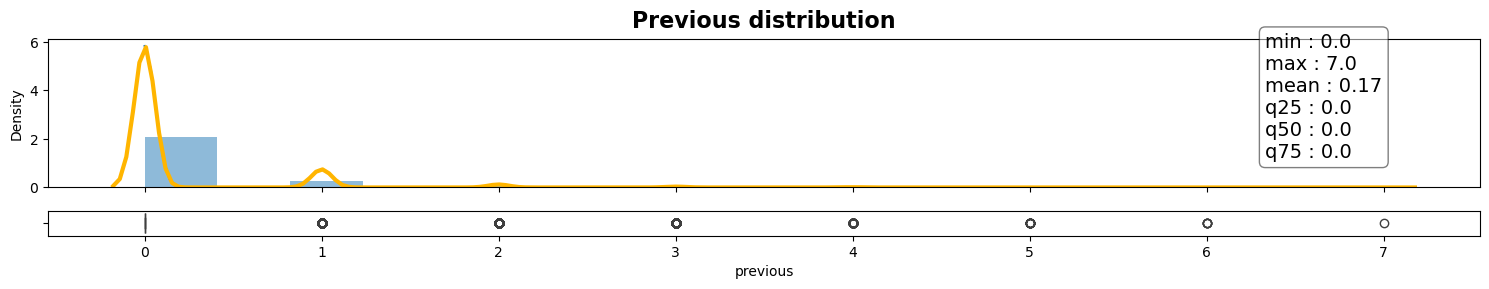

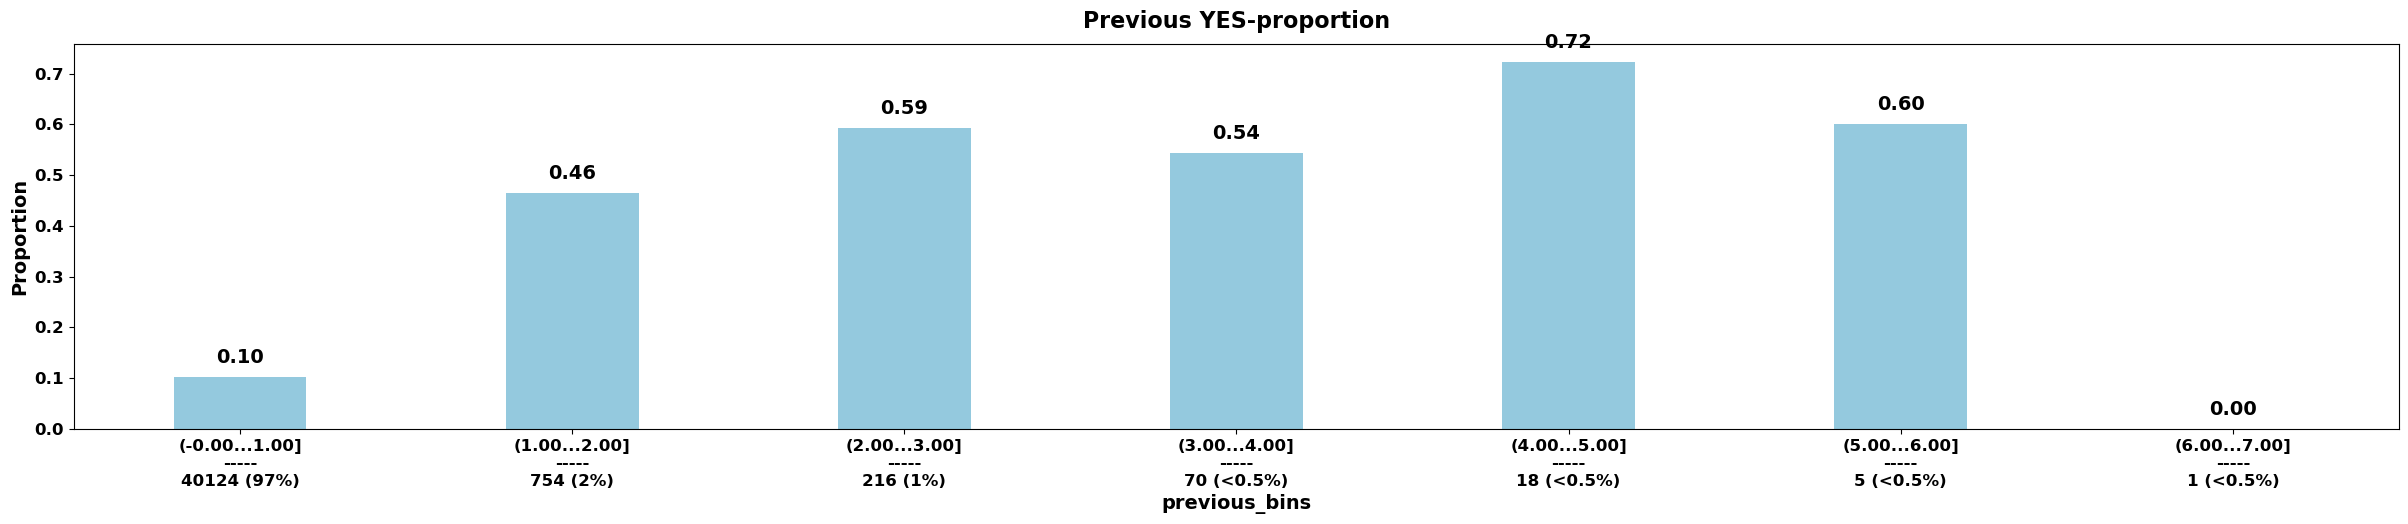

In [183]:
my_file.plot_numeric_distribution(tele_df, 'previous')
fig, ax = plt.subplots(figsize=(30, 5))
my_file.plot_numeric_yes_proportion(tele_df, 'previous', 'y_binary', 10, 0.4, ax=ax, fig=fig)
plt.show()

In [155]:
import importlib
importlib.reload(my_file)

<module 'src.my_file' from 'e:\\Bank-Telemarketing\\notebooks\\..\\src\\my_file.py'>